# 1. Environment Setup

In [1]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'matplotlib': 'matplotlib',
    'requests': 'requests',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



In [2]:
import os
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 2. Configuration

In [3]:
DIR = "../data"

SAMPLED_PARQUET= os.path.join(DIR, "processed/amazon_reviews_s10.parquet")
MULTIMODAL_PARQUET = os.path.join(DIR, "processed/multimodal_s10.parquet")
IMAGE_DIR = os.path.join(DIR, "images")

os.makedirs(IMAGE_DIR, exist_ok=True)

# 3. Load the dataset

In [4]:
df = pd.read_parquet(SAMPLED_PARQUET)

print("Dataset size:", len(df))

Dataset size: 846757


## 3.1. Dataset Preview

In [5]:
df.head()

,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin
0,5,439,5.1744,0,9163,1,2.079442,2,0,5,27,0.065534,[],Incredibly rigid and strong [SEP] We have a 60...,0,1,B07RHQJT1V
1,1,1600,5.1974,0,5207,1,2.397895,2,0,0,14,0.008827,[],Don't Buy This [SEP] This is one of the worst ...,1,4,B003D78O1Y
2,2,122,7.1111,0,7799,1,2.639057,1,0,0,9,0.079646,[],Two Stars [SEP] This actually started rusting ...,0,1,B072FVHDSB
3,1,224,5.6098,1,9350,1,5.521461,2,0,0,7,0.032258,"[{'attachment_type': 'IMAGE', 'large_image_url...",Garbage [SEP] Handle to Lock Screen in place s...,0,1,B07BQ11SBV
4,5,337,5.2769,0,7292,1,6.375025,2,0,0,33,0.108553,[],Comfortable way to carry a camera [SEP] This i...,0,1,B00GR8KEMS


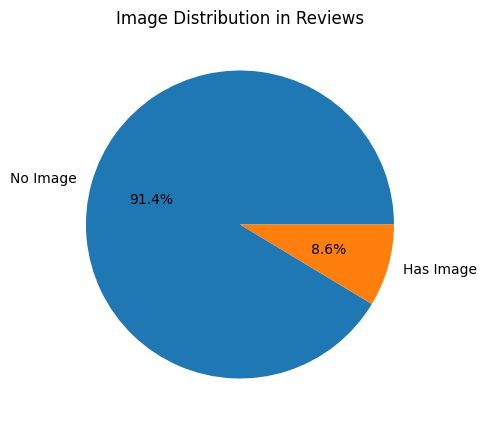


📸 Image Distribution:
  Has Image: 73,125 reviews (8.6%)
  No Image: 773,632 reviews (91.4%)


In [6]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

In [7]:
# Debug: Check the structure of images data
print("Sample image data:")
for i in range(25, 28):
    print(f"\nRow {i}:")
    print(f"  Type: {type(df['images'].iloc[i])}")
    print(f"  Value: {df['images'].iloc[i]}")
    if isinstance(df['images'].iloc[i], list) and len(df['images'].iloc[i]) > 0:
        print(f"  First item type: {type(df['images'].iloc[i][0])}")
        print(f"  First item: {df['images'].iloc[i][0]}")

Sample image data:

Row 25:
  Type: <class 'numpy.ndarray'>
  Value: []

Row 26:
  Type: <class 'numpy.ndarray'>
  Value: []

Row 27:
  Type: <class 'numpy.ndarray'>
  Value: []


# 4. Extract Image Outline

In [8]:
def extract_first_image_url(images_column):

    if isinstance(images_column, np.ndarray):
        images_column = images_column.tolist()

    # Empty list
    if len(images_column) == 0:
        return None

    first = images_column[0]

    # Priority selection
    return (
        first.get("large_image_url")
        or first.get("medium_image_url")
        or first.get("small_image_url")
    )

## 4.1. Create URL column

In [9]:
df["image_url"] = df["images"].apply(extract_first_image_url)

print("Images available:", df["image_url"].notna().sum())

Images available: 73125


In [10]:
df.iloc[19:23][["images", "image_url"]]

,images,image_url
19,[],NaN
20,[],NaN
21,[],NaN
22,[],NaN


# 5. Download Image

In [11]:
def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=5)

        if response.status_code != 200:
            # print(f"HTTP Error {response.status_code}: {url}")
            return False

        image = Image.open(BytesIO(response.content))
        image.verify()  # validate image

        with open(save_path, "wb") as f:
            f.write(response.content)

        return True

    except requests.exceptions.Timeout:
        print(f"Timeout: {url}")
        return False
    except requests.exceptions.ConnectionError:
        print(f"Connection Error: {url}")
        return False
    except Exception as e:
        print(f"Error: {type(e).__name__} - {url}")
        return False

## 5.1. Download Loop

In [12]:
success = 0
failed = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    url = row["image_url"]

    if pd.isna(url):
        continue

    filename = f"{idx}.jpg"
    save_path = os.path.join(IMAGE_DIR, filename)

    # Skip already downloaded images
    if os.path.exists(save_path):
        success += 1
        continue

    ok = download_image(url, save_path)

    if ok:
        success += 1
    else:
        failed += 1

print(f"\n\nDownloaded: {success}")
print(f"Failed: {failed}")

 13%|█▎        | 106413/846757 [13:51<13:20:01, 15.42it/s]

Timeout: https://images-na.ssl-images-amazon.com/images/I/719zvOE5ckL.jpg


 14%|█▍        | 120935/846757 [16:00<12:28:30, 16.16it/s]

Timeout: https://m.media-amazon.com/images/I/61LHo92lE7L._SL1600_.jpg


 15%|█▌        | 128172/846757 [17:23<21:51:48,  9.13it/s]

...

Timeout: https://m.media-amazon.com/images/I/71FSdNAWViL._SL1600_.jpg


 77%|███████▋  | 653031/846757 [1:31:54<1:27:54, 36.73it/s]

Timeout: https://m.media-amazon.com/images/I/71jy2YOzLsL._SL1600_.jpg


 79%|███████▊  | 665693/846757 [1:33:19<25:23, 118.88it/s] 


KeyboardInterrupt: 

# 6. Save Image Mapping

In [ ]:
def get_path(i):   
    p = os.path.join(IMAGE_DIR, f"{i}.jpg")
    return p if os.path.exists(p) else None

df["image_path"] = df.index.map(get_path)

In [ ]:
df.iloc[13:17][["image_url", "image_path", "image_bucket"]]

,image_url,image_path,image_bucket
13,NaN,NaN,0
14,NaN,NaN,0
15,https://images-na.ssl-images-amazon.com/images...,../data\images\15.jpg,1
16,NaN,NaN,0


# 7. Drop redundant features

In [ ]:
drop_cols = ["images", "image_url"]
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

In [ ]:
print(f"Dataset shape: {df.shape[0]:2,} rows x {df.shape[1]} columns")

print(f"\nDataset Columns with dtypes: \n{df.dtypes}")

Dataset shape: 846,757 rows x 17 columns

Dataset Columns with dtypes: 
rating                         int8
review_length                 int32
chars_per_word              float64
image_bucket                  int64
days_since_first_review       int32
is_verified                    int8
log_popularity              float64
rating_extremity               int8
question_mark                 int16
exclamation_mark              int16
title_length                  int16
title_to_text_ratio         float32
combined_text                   str
is_helpful                     int8
helpful_vote                  int32
parent_asin                category
image_path                      str
dtype: object


In [ ]:
df.to_parquet(MULTIMODAL_PARQUET, index=False)

print("Dataset updated with image paths.")

Dataset updated with image paths.
